# Jawad Hassan
# 2230-0035
# BS AI
# ANN
# Lab 10


### Task:
### LSTM WITH STOCK DATASET

/tmp/ipykernel_1338/3341086621.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('TSLA', start='2016-01-01', end='2026-05-14')
[*********************100%***********************]  1 of 1 completed


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0238
Epoch 2/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.0856e-04
Epoch 3/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.0965e-04
Epoch 4/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.8593e-04
Epoch 5/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.7512e-04
Epoch 6/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.6490e-04
Epoch 7/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.2734e-04
Epoch 8/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.1724e-04
Epoch 9/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.6447e-04
Epoch 10/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.5632e-04
Epoch 11/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.6060e-04
Epoch 12/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.1048e-04
Epoch 13/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.5947e-04
Epoch 14/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.4521e-04
Epoch 15/15
65/65 ━━━━━━━━━━━━━━━

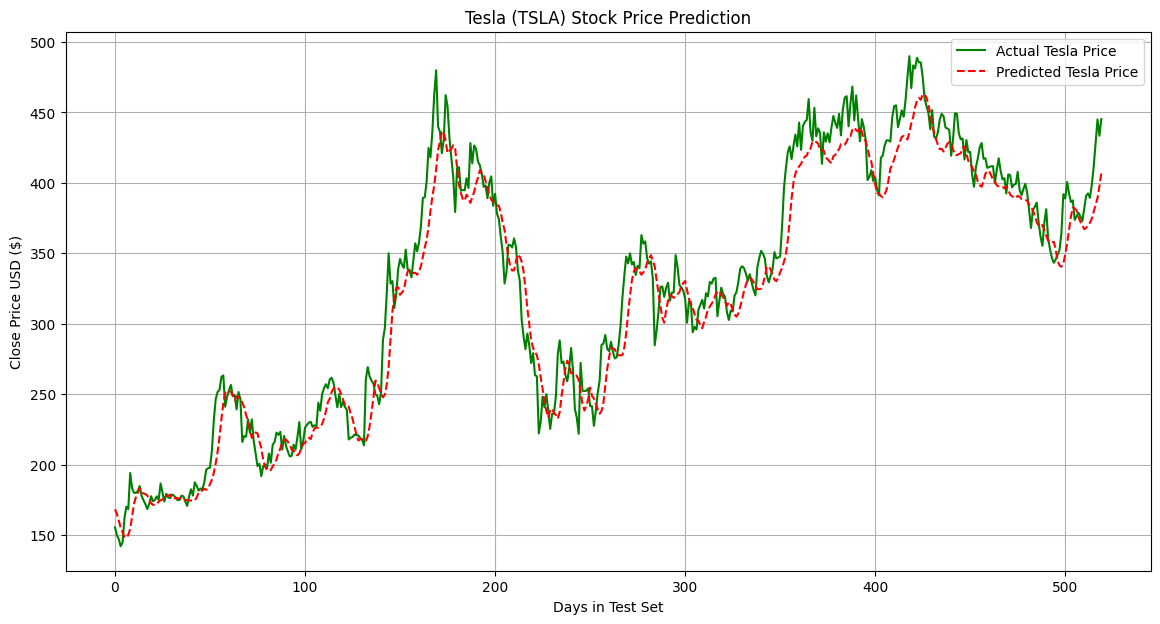

In [5]:
# ==========================================
# STEP 0: Download Tesla Data via yfinance
# ==========================================
# Install the Yahoo Finance library
!pip install yfinance -q

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

# Download Tesla data from 2016 to the current date
print("Downloading Tesla stock data...")
df = yf.download('TSLA', start='2016-01-01', end='2026-05-14')


# STEP 1: Preprocess Data

# Safest way to extract the 'Close' column with newer yfinance versions
close_prices = df['Close']

# Convert to a numpy array and force it to be a 2D shape (Rows x 1 Column)
data = close_prices.values.reshape(-1, 1)

# Normalize values between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# STEP 2: Create Sequences (Last 5 days -> Next day)

seq_length = 5
X = []
y = []

for i in range(seq_length, len(scaled_data)):
    X.append(scaled_data[i-seq_length:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)


# STEP 3: Split Data (80% Train, 20% Test)

# No shuffling because stock data is time-dependent
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Reshape input to be [samples, time steps, features] for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# STEP 4: Train LSTM Model

model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(32, return_sequences=False))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
model.fit(X_train, y_train, batch_size=32, epochs=15, verbose=1)


# STEP 5: Make Predictions

predictions = model.predict(X_test)
# Undo normalization to get actual dollar prices
predictions = scaler.inverse_transform(predictions)

# Get actual prices for the test period for comparison
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))


# STEP 6: Plot Results

plt.figure(figsize=(14, 7))
plt.title('Tesla (TSLA) Stock Price Prediction')
plt.xlabel('Days in Test Set')
plt.ylabel('Close Price USD ($)')

plt.plot(actual_prices, color='green', label='Actual Tesla Price')
plt.plot(predictions, color='red', linestyle='--', label='Predicted Tesla Price')

plt.legend()
plt.grid(True)
plt.show()